# Permeator Probe plotting and post-processing for FESTIM simulation results. 

## Steady State Analysis 

Compare inlet, outlet, and probe surface fluxes. 

In [1]:
import numpy as np


permeation_flux = np.genfromtxt(
    "festim_results_probe_out_benchmark/permeation_flux.csv", delimiter=",", names=True
)
outlet_advective_flux = np.genfromtxt(
    "festim_results_probe_out_benchmark/outlet_advective_flux.csv", delimiter=",", names=True
)
inlet_advective_flux = np.genfromtxt(
    "festim_results_probe_out_benchmark/inlet_advective_flux.csv", delimiter=",", names=True
)

probe_flux = permeation_flux["H_flux_surface_7"]
outlet_flux = outlet_advective_flux["H_advection_flux_surface_6"]
inlet_flux = -inlet_advective_flux["H_advection_flux_surface_4"]

# assert probe_flux + outlet_flux <= inlet_flux # mass conservation 

percent_lost_to_permeation = probe_flux/inlet_flux * 100
percent_at_outlet = outlet_flux/inlet_flux * 100

print(f"Permeation flux into probe is {percent_lost_to_permeation}% of inlet flux.")
print(f"Advective flux at outlet is {percent_at_outlet}% of inlet flux.")



Permeation flux into probe is 0.09320545463099085% of inlet flux.
Advective flux at outlet is 100.93990236907744% of inlet flux.


Calculate the pressure drop from inlet to outlet, based off of paraview-extracted data from OpenFOAM.

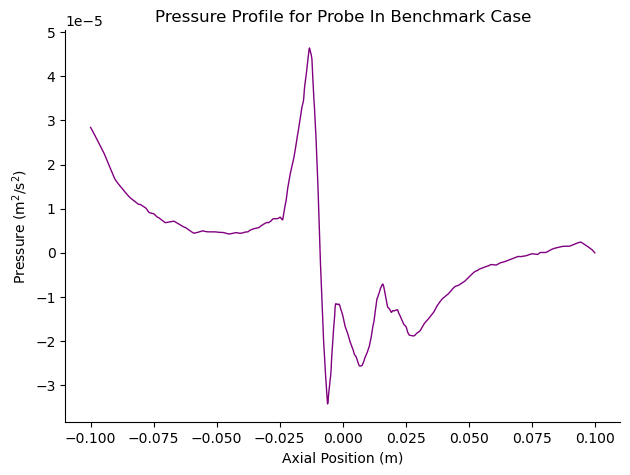

Pressure drops by 99.53712496922374% between inlet and outlet.
Pressure drop between inlet and outlet is 2.82994e-05 m2/s2.


In [2]:
import matplotlib.pyplot as plt

pressure_file = np.genfromtxt(
    "festim_results_probe_in_benchmark/pressure.csv", delimiter=",", names=True
)
pressure = pressure_file["p"]
axial_position = pressure_file["Points1"]

plt.figure()
plt.plot(axial_position, pressure, color="purple", linewidth=1)
plt.xlabel("Axial Position (m)")
plt.ylabel(r"Pressure (m$^2$/s$^2$)")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.title("Pressure Profile for Probe In Benchmark Case")
plt.show()

percent_change = (pressure[0]-pressure[-2])/pressure[0] * 100 # pressure[-2] because we enforce p =0 at outlet 

print(f"Pressure drops by {percent_change}% between inlet and outlet.")
print(f"Pressure drop between inlet and outlet is {pressure[0]-pressure[-2]} m2/s2.")



## OpenFOAM Abacus Post Processing

Generate abacus for various flow rates and impact on permeation flux.

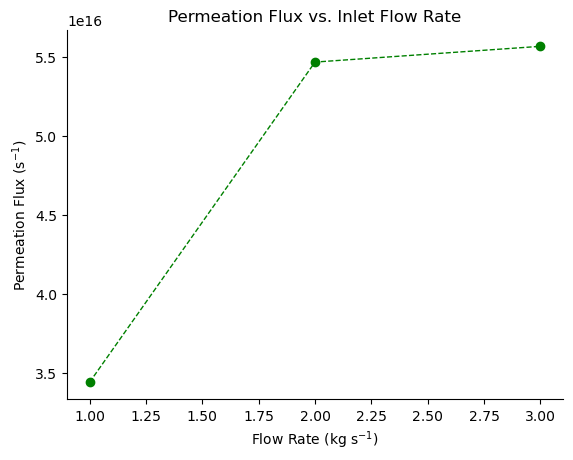

In [12]:
flow_rates = [1,2,3,]#4] # kg/s 

# first flow rate is benchmark case 
permeation_1kgs = np.genfromtxt(
    "festim_results_probe_in_benchmark/permeation_flux.csv", delimiter=",", names=True
)
outlet_1kgs = np.genfromtxt(
    "festim_results_probe_in_benchmark/outlet_advective_flux.csv", delimiter=",", names=True
)

permeation_fluxes = [permeation_1kgs["H_flux_surface_7"]]
outlet_fluxes = [outlet_1kgs["H_advection_flux_surface_6"]]

for rate in flow_rates[1:]:
    file_path = f"festim_{rate}kg_s_probe_in"
    permeation = np.genfromtxt(
        file_path+"/permeation_flux.csv", delimiter=",", names=True
    )
    outlet = np.genfromtxt(
        file_path+"/outlet_advective_flux.csv", delimiter=",", names=True
    )

    permeation_fluxes.append(permeation["H_flux_surface_7"])
    outlet_fluxes.append(outlet["H_advection_flux_surface_6"])

plt.figure()
plt.scatter(flow_rates, permeation_fluxes, color="green", linewidth=1)
plt.plot(flow_rates, permeation_fluxes, color="green", linestyle='--', linewidth=1)
plt.xlabel(r"Flow Rate (kg s$^{-1}$)")
plt.ylabel(r"Permeation Flux (s$^{-1}$)")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.title("Permeation Flux vs. Inlet Flow Rate")
plt.show()


## FESTIM Abacus Post Processing

Generate abacus for various inlet concentrations and impact on permeation flux. 

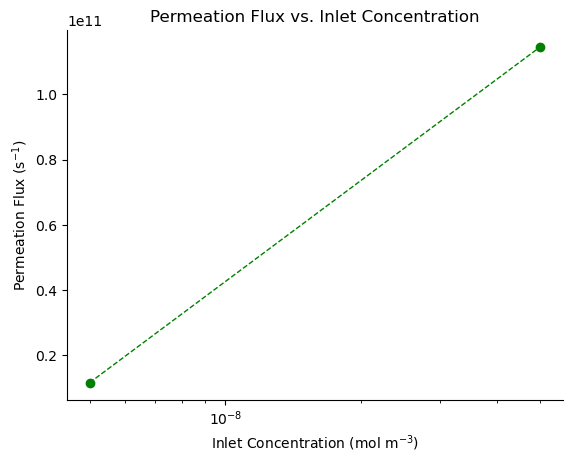

In [14]:
inlet_concentrations = mol_m3_c_in = [
    5e-09,
    5e-08,
    # 5e-07,
    # 5e-06,
    # 5e-05,
    # 5e-04,
    # 5e-03,
    # 5e-02,
    # 5e-01,
    # 5,
    # 5e01,
]  # mol/m3

permeation_fluxes = []
outlet_fluxes = []

for conc in inlet_concentrations:
    file_path = f"festim_results_cin_{conc}_mol_m3"
    permeation = np.genfromtxt(
        file_path+"/permeation_flux.csv", delimiter=",", names=True
    )
    outlet = np.genfromtxt(
        file_path+"/outlet_advective_flux.csv", delimiter=",", names=True
    )

    permeation_fluxes.append(permeation["H_flux_surface_7"])
    outlet_fluxes.append(outlet["H_advection_flux_surface_6"])

plt.figure()
plt.scatter(inlet_concentrations, permeation_fluxes, color="green", linewidth=1)
plt.plot(inlet_concentrations, permeation_fluxes, color="green", linestyle='--', linewidth=1)
plt.xscale('log')
plt.xlabel(r"Inlet Concentration (mol m$^{-3}$)")
plt.ylabel(r"Permeation Flux (s$^{-1}$)")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.title("Permeation Flux vs. Inlet Concentration")
plt.show()


## Transient Analysis

Plot to compare advective flux at breeder outlet to permeation flux at probe surface. 

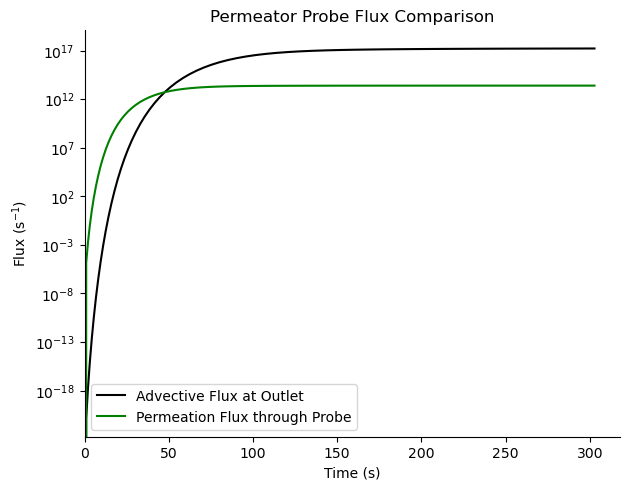

In [8]:
import matplotlib.pyplot as plt
import numpy as np


outlet_surface_flux = np.genfromtxt(
    "festim_results/outlet_surface_flux.csv", delimiter=",", names=True
)

advective_flux_outlet_t = outlet_surface_flux["ts"] # time
advective_flux_outlet = outlet_surface_flux["H_advection_flux_surface_2"] # field

# append t=0 value=0 at start of data
advective_flux_outlet_t = np.insert(advective_flux_outlet_t, 0, 0)
advective_flux_outlet = np.insert(advective_flux_outlet, 0, 0)

probe_surface_flux = np.genfromtxt(
    "festim_results/probe_surface_flux.csv", delimiter=",", names=True
)

permeation_flux_probe_t = probe_surface_flux["ts"] # time
permeation_flux_probe = probe_surface_flux["H_flux_surface_4"] # field

# append t=0 value=0 at start of data
permeation_flux_probe_t = np.insert(permeation_flux_probe_t, 0, 0)
permeation_flux_probe = np.insert(permeation_flux_probe, 0, 0)

plt.figure()
plt.plot(advective_flux_outlet_t, advective_flux_outlet, color="black", label="Advective Flux at Outlet")
plt.plot(permeation_flux_probe_t, permeation_flux_probe, color="green", label="Permeation Flux through Probe")
# plt.fill_between(permeation_flux_probe_t, permeation_flux_probe, color="green", alpha=0.5)
plt.xlabel("Time (s)")
plt.ylabel(r"Flux (s$^{-1}$)")
plt.xlim(left=0)
plt.yscale('log')
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.legend()
plt.tight_layout()
plt.title("Permeator Probe Flux Comparison")

plt.show()

Plot for permeation flux at probe surface.

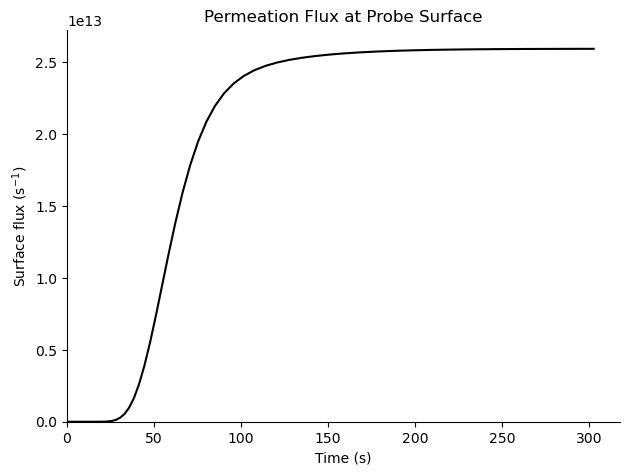

In [3]:
import matplotlib.pyplot as plt
import numpy as np


probe_surface_flux = np.genfromtxt(
    "festim_results/probe_surface_flux.csv", delimiter=",", names=True
)

surface_flux_t = probe_surface_flux["ts"] # time
surface_flux = probe_surface_flux["H_flux_surface_4"] # field

# append t=0 value=0 at start of data
surface_flux_t = np.insert(surface_flux_t, 0, 0)
surface_flux = np.insert(surface_flux, 0, 0)

plt.figure()
plt.plot(surface_flux_t, surface_flux, color="black")
plt.xlabel("Time (s)")
plt.ylabel(r"Surface flux (s$^{-1}$)")
plt.xlim(left=0)
plt.ylim(bottom=0)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.title("Permeation Flux at Probe Surface")

plt.show()